# Confidence-based SAM3 facade classification

This notebook is a variant of `ams-map-workflow.ipynb`. When facade masks overlap, it doesn't use a fixed
hierarchy (glass > brick > concrete) to get non-overlapping masks. Instead, each pixel is assigned to the
facade class of the **most confident** SAM3 instance covering it.

The following commands were used to create the database and segmentation:

```bash
streetscapes config set active_project amsterdam-final
streetscapes fetch-metadata mapillary 4.864883 52.320862 4.983330 52.385973 --pano-only --daytime-only --tile-size 0.0005 --images-per-tile 5
streetscapes download-images mapillary
streetscapes segment-images sam3 --prompt "building,brick facade,concrete facade,glass facade" --batch-size 20
```

In [ ]:
from streetscapes.utils.db_access import get_image, get_image_path, get_segmentations, open_project

PROJECT = "amsterdam-final"

db = open_project(PROJECT, read_only=True)

## Scaling confidence

Model confidence sadly doesn't compare very well between different classes.
For example, the model can be more skilled at detecting concrete facades, and therefore assign a higher confidence levelwhen it detects one.
Using weighting based on the confidence distribution of different classes did not seem to work well, therefore this notebook uses a scaling factor per class so the end user can manually scale the relative importance of each class:

In [ ]:
# enter the run ID of the SAM3 segmentation run you want to use:
RUN_ID = "sam3-2026-09-18T11:01:36.418"

# Facade classes, in the order used for the (R, G, B) colors further on.
CATEGORIES = ("brick facade", "concrete facade", "glass facade")

# Number of randomly sampled images to process. Set to None to process all images.
N_IMAGES = 500
SEED = 41

# Per-class factor that the model confidence is multiplied by before picking the most confident mask.
# Use this to correct for the model being more (or less) confident about certain prompts.
# All 1.0 means the raw model confidence is used.
CONFIDENCE_SCALING = {
    "brick facade": 1.0,
    "concrete facade": 0.5,
    "glass facade": 0.75,
}

## Confidence-based facade masks

Every instance returned by SAM3 has a confidence score. To get non-overlapping masks, all facade instances
of an image are rasterized in order of *increasing* confidence, each writing its class ID into a label
image. Later (more confident) instances overwrite earlier ones, so every pixel ends up with the class of
the most confident instance that covers it. This is equivalent to taking the argmax over the per-class
maximum confidence.

In [13]:
import numpy as np
import rasterio.features
from PIL import Image


def get_run(segmentations, run_id):
    for seg in segmentations:
        if seg.id == run_id:
            return seg
    return None


def facade_class_map(instances, shape, scaling=None, categories=CATEGORIES):
    """Label image: 0 = no facade, i + 1 = categories[i] (most confident instance wins).

    `scaling` optionally maps each label to a factor that its confidences are multiplied by.
    """
    facades = [inst for inst in instances if inst.label in categories]
    if scaling is None:
        facades.sort(key=lambda inst: inst.confidence)
    else:
        facades.sort(key=lambda inst: inst.confidence * scaling[inst.label])
    if not facades:
        return np.zeros(shape, dtype=np.uint8)
    return rasterio.features.rasterize(
        [(inst.polygon, categories.index(inst.label) + 1) for inst in facades],
        out_shape=shape,
        fill=0,
        dtype=np.uint8,
    )


def facade_class_map_hierarchy(instances, shape, categories=CATEGORIES):
    """The original fixed hierarchy (glass > brick > concrete), for comparison."""
    masks = {}
    for label in categories:
        polys = [inst.polygon for inst in instances if inst.label == label]
        masks[label] = (
            rasterio.features.rasterize(polys, out_shape=shape, dtype=np.uint8) > 0
            if polys else np.zeros(shape, dtype=bool)
        )
    class_map = np.zeros(shape, dtype=np.uint8)
    for label in ("concrete facade", "brick facade", "glass facade"):  # lowest priority first
        class_map[masks[label]] = categories.index(label) + 1
    return class_map


def image_shape(uuid):
    # Only reads the image header; much faster than decoding the full panorama.
    with Image.open(get_image_path(uuid, project=PROJECT)) as im:
        w, h = im.size
    return h, w

### Scaling confidences per class

The model's confidences are not necessarily comparable between prompts: a class that SAM3 is generally more
confident about would win most overlaps. With `CONFIDENCE_SCALING` you can give each class a factor that its
confidences are multiplied by before comparing them. The confidence distribution per class (over all images
in the segmentation run) can help you choose these factors:

In [14]:
segs = db.table("segmentations")
run_segs = segs.filter(segs.run == RUN_ID)
all_instances = run_segs.select(label=run_segs.labels.unnest(), confidence=run_segs.confidences.unnest())
(
    all_instances.filter(all_instances.label.isin(CATEGORIES))
    .to_pandas()
    .groupby("label")["confidence"]
    .describe(percentiles=[0.1, 0.5, 0.9])
)

,count,mean,std,min,10%,50%,90%,max
label,,,,,,,,
brick facade,83932.0,0.415820,0.143972,0.250000,0.265783,0.371262,0.641136,0.947913
concrete facade,154799.0,0.425400,0.143324,0.250000,0.268375,0.388771,0.641806,0.946510
glass facade,100204.0,0.376154,0.128747,0.250002,0.261306,0.331600,0.561997,0.969610


### Comparison on a single image

The methods side by side (red: brick, green: concrete, blue: glass):

6b964956-af2d-91ef-e6ba-babc3573c07e: 11.9% of pixels differ between both methods


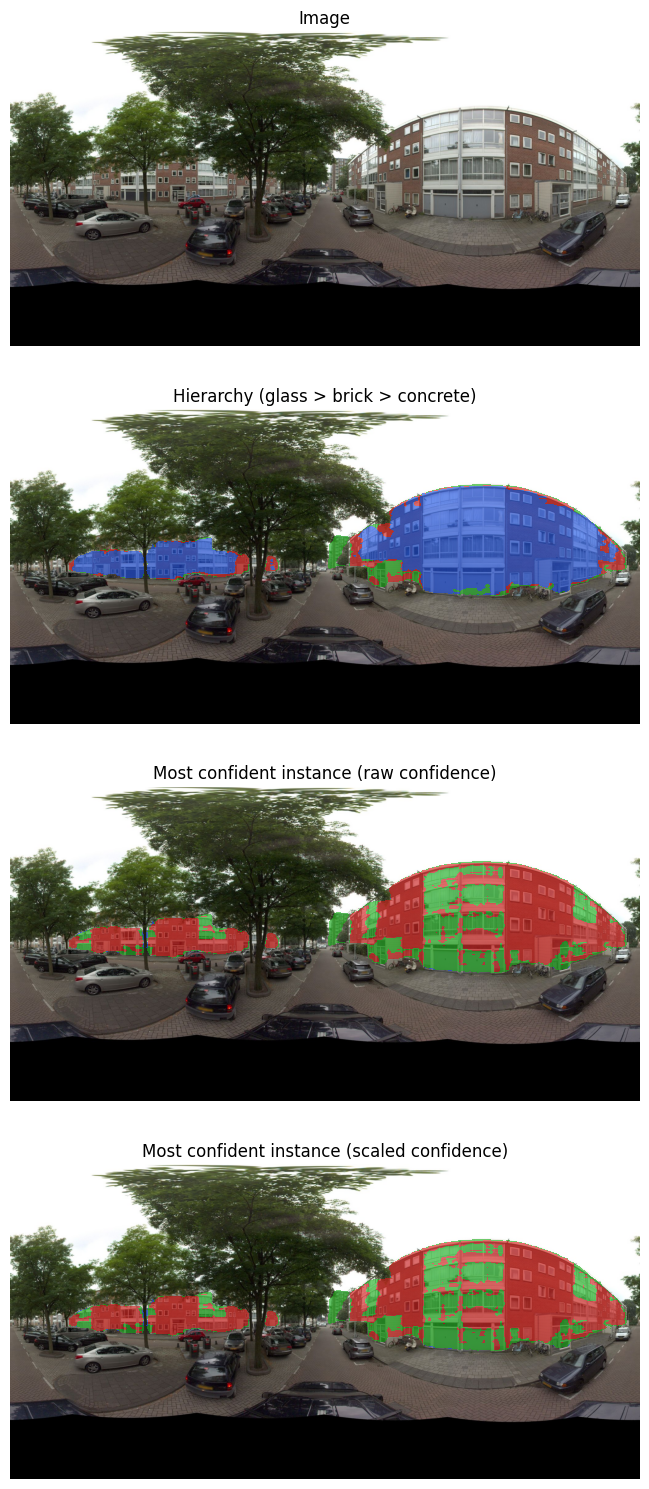

In [15]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

images = db.table("images").uuid.to_pandas().astype(str)
rng = np.random.default_rng(SEED)
subset = images if N_IMAGES is None else images.iloc[rng.choice(len(images), N_IMAGES, replace=False)]

# Pick the image (out of the first 30 in the subset) where the hierarchy and the confidence-based
# method (with the chosen scaling) disagree the most.
best_diff = -1
for uuid in subset.iloc[:30]:
    seg = get_run(get_segmentations(uuid, project=PROJECT), RUN_ID)
    if seg is None:
        continue
    shape = image_shape(uuid)
    diff = np.mean(
        facade_class_map(seg.instances, shape, CONFIDENCE_SCALING) != facade_class_map_hierarchy(seg.instances, shape)
    )
    if diff > best_diff:
        best_diff, example_uuid, example_seg, example_shape = diff, uuid, seg, shape
print(f"{example_uuid}: {best_diff:.1%} of pixels differ between both methods")

panels = [
    ("Image", None),
    ("Hierarchy (glass > brick > concrete)", facade_class_map_hierarchy(example_seg.instances, example_shape)),
    ("Most confident instance (raw confidence)", facade_class_map(example_seg.instances, example_shape)),
]
if any(factor != 1.0 for factor in CONFIDENCE_SCALING.values()):
    panels.append((
        "Most confident instance (scaled confidence)",
        facade_class_map(example_seg.instances, example_shape, CONFIDENCE_SCALING),
    ))

cmap = ListedColormap([(0, 0, 0, 0), (0.85, 0.1, 0.1, 0.6), (0.1, 0.7, 0.1, 0.6), (0.1, 0.3, 0.9, 0.6)])
fig, axes = plt.subplots(nrows=len(panels), figsize=(12, 4.7 * len(panels)))
for ax, (title, cm) in zip(axes, panels):
    ax.imshow(get_image(example_uuid))
    if cm is not None:
        ax.imshow(cm, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

## Facade fractions per image

In [16]:
from tqdm import tqdm

m = db.table("mapillary")
locations = (
    m.filter(m.image.isin(subset.tolist()))
    .select("image", "geometry")
    .to_pandas()
    .assign(image=lambda df: df["image"].astype(str))
    .drop_duplicates("image")
    .set_index("image")["geometry"]
)

result = {}

for uuid in tqdm(subset):
    seg = get_run(get_segmentations(uuid, project=PROJECT), RUN_ID)
    if seg is None or uuid not in locations.index:
        continue

    h, w = image_shape(uuid)
    class_map = facade_class_map(seg.instances, (h, w), CONFIDENCE_SCALING)

    # fraction of image pixels per facade class
    counts = np.bincount(class_map.ravel(), minlength=len(CATEGORIES) + 1)[1:]
    fractions = counts / (h * w)

    # normalize to fraction of facades
    total_frac = fractions.sum()
    if total_frac > 0.05:  # at least 5% pixels must be a building
        result[locations[uuid]] = tuple(fractions / total_frac)

print(f"{len(result)} of {len(subset)} images have enough facade pixels")

100%|██████████| 19956/19956 [41:18<00:00,  8.05it/s]  

13443 of 19956 images have enough facade pixels


Now we can plot this as a scatterplot

Text(0.5, 1.0, 'R: brick, G: concrete, B: glass')

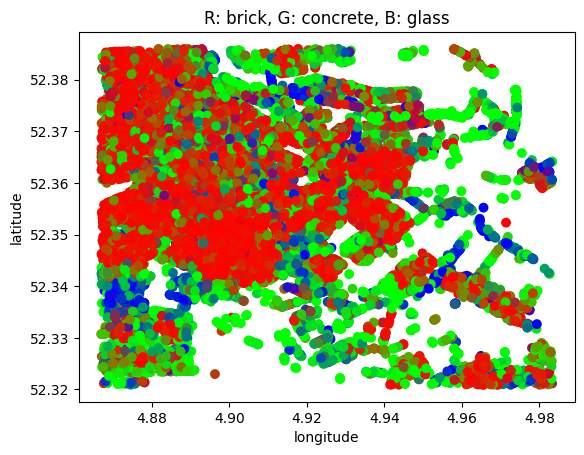

In [17]:
for loc, color in result.items():
    plt.scatter(loc.x, loc.y, s=50, facecolors=color, edgecolors="none")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("R: brick, G: concrete, B: glass")

Scatterplot with base map

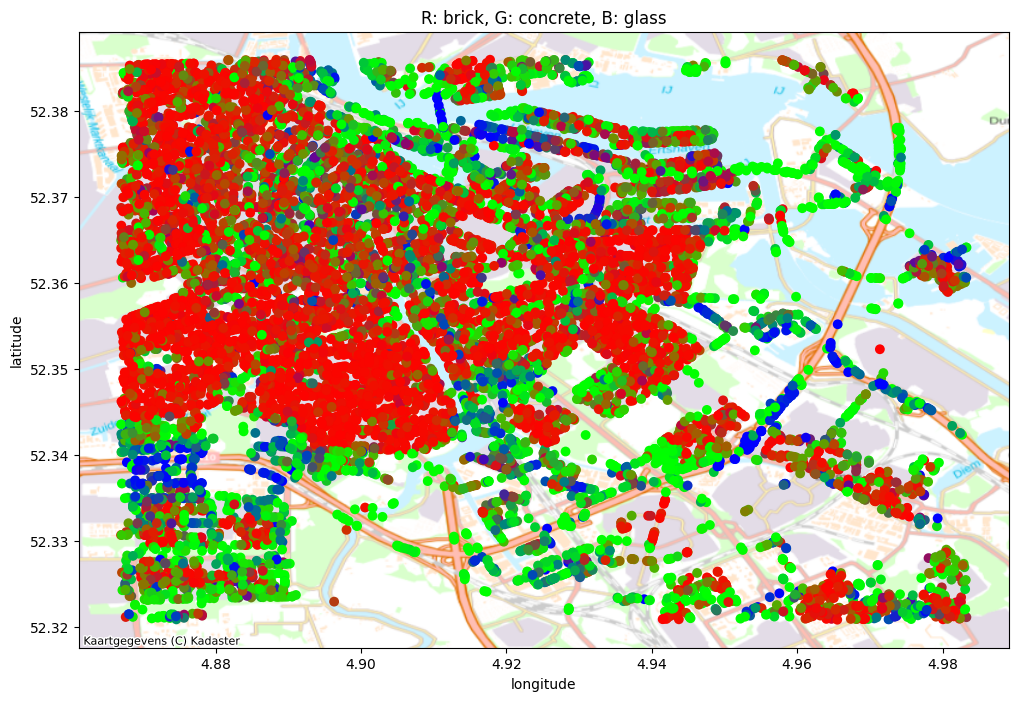

In [18]:
import contextily

fig, ax = plt.subplots(figsize=(12, 8))

for loc, color in result.items():
    ax.scatter(loc.x, loc.y, s=50, facecolors=color, edgecolors="none")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("R: brick, G: concrete, B: glass")
contextily.add_basemap(ax, crs="EPSG:4326", source=contextily.providers.nlmaps.pastel)

Rasterize the point data:

In [19]:
import math

import geopandas
import rasterio.transform

gdf = geopandas.GeoDataFrame(
    {
        "brick": [c[0] for c in result.values()],
        "concrete": [c[1] for c in result.values()],
        "glass": [c[2] for c in result.values()],
        "geometry": list(result.keys()),
    },
    crs="EPSG:4326",
)
ams_proj = gdf.to_crs(28992)

bounds = ams_proj.total_bounds
horizontal_resolution = 250
transform = rasterio.transform.from_origin(
    west=bounds[0],
    north=bounds[3],
    xsize=horizontal_resolution,
    ysize=horizontal_resolution,
)

rows = math.ceil((bounds[3] - bounds[1]) / horizontal_resolution)
cols = math.ceil((bounds[2] - bounds[0]) / horizontal_resolution)
shape = (rows, cols)

rasters = {
    name: rasterio.features.rasterize(
        shapes=ams_proj[["geometry", name]].to_numpy().tolist(),
        out_shape=shape,
        transform=transform,
        fill=np.nan,
    )
    for name in ("brick", "concrete", "glass")
}

Plot the rasterized data:

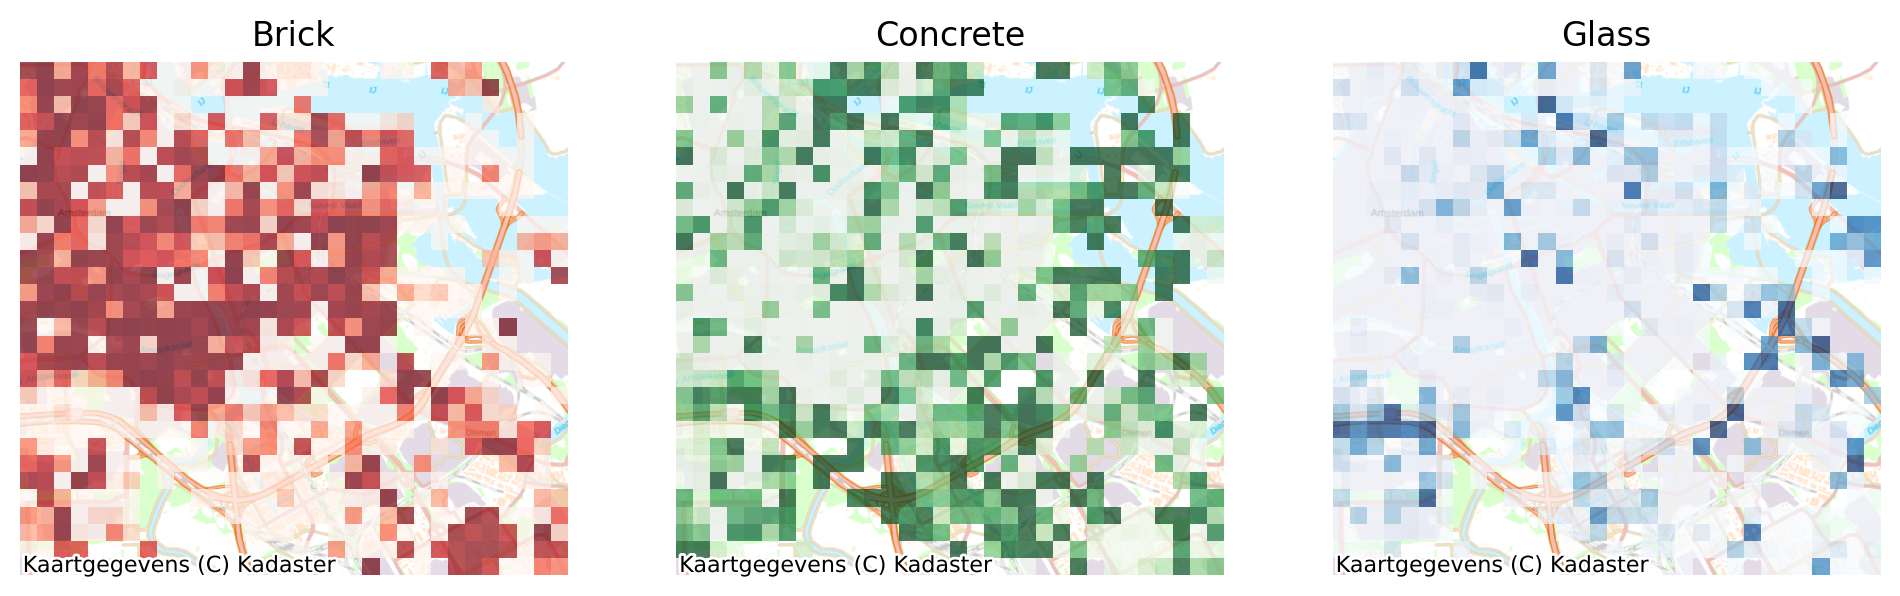

In [20]:
import rasterio.plot

fig, axes = plt.subplots(figsize=(12, 5), ncols=3, sharex=True, sharey=True, dpi=200)

for ax, (name, raster), cmap_name in zip(axes, rasters.items(), ("Reds", "Greens", "Blues")):
    rasterio.plot.show(raster, transform=transform, ax=ax, vmin=0, vmax=1, cmap=cmap_name, alpha=0.7)
    contextily.add_basemap(ax, crs=ams_proj.crs, source=contextily.providers.nlmaps.pastel)
    rasterio.plot.show(raster, transform=transform, ax=ax, vmin=0, vmax=1, cmap=cmap_name, alpha=0.7)
    ax.set_title(name.capitalize())
    ax.axis("off")

## Export to an xarray dataset

Finally, the rasterized facade fractions are stored in an xarray dataset:

In [22]:
import json

import xarray as xr
from pyproj import CRS

# Coordinates of the raster cell centers
x = transform.c + (np.arange(cols) + 0.5) * transform.a
y = transform.f + (np.arange(rows) + 0.5) * transform.e

crs = CRS.from_user_input(ams_proj.crs)
ds = xr.Dataset(
    {
        f"{material}_fraction": (
            ("y", "x"),
            raster,
            {
                "long_name": f"Fraction of {material} facade (of all facade pixels)",
                "units": "-",
                "grid_mapping": "spatial_ref",
            },
        )
        for material, raster in rasters.items()
    },
    coords={
        "x": ("x", x, {"standard_name": "projection_x_coordinate", "units": "m"}),
        "y": ("y", y, {"standard_name": "projection_y_coordinate", "units": "m"}),
        "spatial_ref": ((), 0, {**crs.to_cf(), "spatial_ref": crs.to_wkt(), "GeoTransform": " ".join(map(str, transform.to_gdal()))}),
    },
    attrs={
        "source": f"streetscapes project '{PROJECT}', segmentation run '{RUN_ID}'",
        "confidence_scaling": json.dumps(CONFIDENCE_SCALING),
    },
)

ds.to_netcdf("facade_fractions_with_confidence.nc")